In [6]:
import pandas as pd
import numpy as np
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.preprocessing import StandardScaler
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)


True

# Load and Preprocess Data

In [ ]:
# import kagglehub

# path = kagglehub.dataset_download("shivamb/real-or-fake-fake-jobposting-prediction")
# df = pd.read_csv(f"{path}/fake_job_postings.csv")

df = pd.read_csv(f"fake_job_postings_augmented.csv")

print(f"Dataset loaded: {df.shape}")
print(f"Fraud rate: {df['fraudulent'].mean()*100:.2f}%\n")

# Combine text fields
def combine_text_fields(row):
    fields = [
        'title', 'location', 'company_profile', 'description',
        'requirements', 'benefits', 'required_experience',
        'required_education', 'industry', 'function'
    ]
    text_parts = []
    for field in fields:
        if pd.notna(row[field]):
            text_parts.append(str(row[field]))
    return ' '.join(text_parts) if text_parts else "unknown job"

df['combined_text'] = df.apply(combine_text_fields, axis=1)

# Preprocess text
def preprocess_text(text):
    if pd.isna(text):
        return ""
    tokens = word_tokenize(str(text).lower())
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token.isalpha() and token not in stop_words]
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return ' '.join(tokens)

df['text_processed'] = df['combined_text'].apply(preprocess_text)

# Create numeric features
location_fraud_ratio = (df.groupby('location')['fraudulent'].sum() /
                       df.groupby('location').size())
df['location_fraud_ratio'] = df['location'].map(location_fraud_ratio).fillna(0.05)
df['character_count'] = df['combined_text'].str.len()

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8,
    stop_words='english'
)

X_text = vectorizer.fit_transform(df['text_processed'])

numeric_features = [
    'telecommuting',
    'has_company_logo',
    'has_questions',
    'location_fraud_ratio',
    'character_count'
]

X_numeric = df[numeric_features].fillna(0).values
X_numeric_sparse = csr_matrix(X_numeric)
X_combined = hstack([X_text, X_numeric_sparse])

y = df['fraudulent'].values

print(f"Feature matrix: {X_combined.shape}")
print(f"Text features: {X_text.shape[1]}")
print(f"Numeric features: {len(numeric_features)}\n")

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"Train set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}\n")

Dataset loaded: (29880, 18)
Fraud rate: 43.06%

Feature matrix: (29880, 5005)
Text features: 5000
Numeric features: 5

Train set size: 20916
Test set size: 8964



## Naive Bayes

In [ ]:
import joblib
from pathlib import Path

models_dir = Path("../models")

nb_model = joblib.load(models_dir / "naive_bayes_model.pkl")

y_pred_nb = nb_model.predict(X_test)
y_pred_proba_nb = nb_model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_nb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_nb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_nb):.4f}\n")


Accuracy: 0.9692
F1-Score: 0.9636
Precision: 0.9817
Recall: 0.9461
ROC-AUC: 0.9824



## LSTM

In [ ]:
print("="*80)
print("PREPARING LSTM DATA")
print("="*80)

import pickle
from tensorflow.keras.preprocessing.sequence import pad_sequences
import re

# Use the SAME tokenizer that was used during LSTM training
with open(models_dir / "lstm_tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

# Use the SAME clean_text function from 04_lstm_model.ipynb
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.strip()

# Use the SAME text column and preprocessing
# The ensemble notebook uses df['text_processed'] (lemmatized)
# but the LSTM was trained on df['text_cleaned'] (clean_text style)
# We need to re-apply clean_text to the combined_text
df['text_for_lstm'] = df['combined_text'].apply(clean_text)

# Use the SAME sequence length from lstm_config.json
import json
with open(models_dir / "lstm_config.json", "r") as f:
    lstm_config = json.load(f)

MAX_SEQ_LEN = lstm_config["MAX_SEQUENCE_LENGTH"]  # 256 or 500

X_sequences = tokenizer.texts_to_sequences(df['text_for_lstm'])
X_padded = pad_sequences(X_sequences, maxlen=MAX_SEQ_LEN)

# Same split as before
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
    X_padded, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"LSTM test shape: {X_test_lstm.shape}")
print(f"Using saved tokenizer vocab: {len(tokenizer.word_index)} words")
print(f"Sequence length: {MAX_SEQ_LEN}")

PREPARING LSTM DATA
LSTM test shape: (8964, 256)
Using saved tokenizer vocab: 151392 words
Sequence length: 256


In [19]:
print("="*80)
print("LOADING LSTM MODEL")
print("="*80)

from tensorflow.keras.models import load_model
from pathlib import Path

models_dir = Path("../models")

# Load the trained LSTM model saved in 04_lstm_model.ipynb
lstm_model = load_model(models_dir / "lstm_model.h5")  # adjust filename if different

# Evaluate on X_test_lstm
y_pred_proba_lstm = lstm_model.predict(X_test_lstm, verbose=0).ravel()
y_pred_lstm = (y_pred_proba_lstm > 0.5).astype(int)

print(f"\nAccuracy: {accuracy_score(y_test_lstm, y_pred_lstm):.4f}")
print(f"F1-Score: {f1_score(y_test_lstm, y_pred_lstm):.4f}")
print(f"Precision: {precision_score(y_test_lstm, y_pred_lstm):.4f}")
print(f"Recall: {recall_score(y_test_lstm, y_pred_lstm):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_lstm, y_pred_proba_lstm):.4f}\n")


LOADING LSTM MODEL

Accuracy: 0.9630
F1-Score: 0.9575
Precision: 0.9466
Recall: 0.9687
ROC-AUC: 0.9882



# Ensemble

In [20]:
print("="*80)
print("BUILDING ENSEMBLE CLASSIFIERS")
print("="*80)

# FIX: Flatten LSTM predictions to match NB shape
y_pred_proba_lstm_flat = y_pred_proba_lstm.flatten()
y_pred_lstm_flat = y_pred_lstm.flatten()

print(f"NB predictions shape: {y_pred_nb.shape}")
print(f"LSTM predictions shape (fixed): {y_pred_lstm_flat.shape}")
print(f"NB probabilities shape: {y_pred_proba_nb.shape}")
print(f"LSTM probabilities shape (fixed): {y_pred_proba_lstm_flat.shape}\n")

# Strategy 1: Hard Voting (majority vote)
y_pred_ensemble_hard = ((y_pred_nb.astype(int) +
                        y_pred_lstm_flat.astype(int)) >= 1).astype(int)

# Strategy 2: Soft Voting (average probabilities)
y_pred_proba_ensemble = (y_pred_proba_nb + y_pred_proba_lstm_flat) / 2.0
y_pred_ensemble_soft = (y_pred_proba_ensemble >= 0.5).astype(int)

# Strategy 3: Weighted Voting (weight by individual performance)
# LSTM: F1=0.6578, NB: F1=0.596 → weight LSTM more heavily
w_lstm = 0.55
w_nb = 0.45
y_pred_proba_ensemble_weighted = (
    w_nb * y_pred_proba_nb +
    w_lstm * y_pred_proba_lstm_flat
)
y_pred_ensemble_weighted = (y_pred_proba_ensemble_weighted >= 0.5).astype(int)

# Strategy 4: Conservative (both agree it's fraud)
y_pred_ensemble_conservative = ((y_pred_nb.astype(int) *
                                 y_pred_lstm_flat.astype(int)) == 1).astype(int)

print("✓ All ensemble strategies created\n")


BUILDING ENSEMBLE CLASSIFIERS
NB predictions shape: (8964,)
LSTM predictions shape (fixed): (8964,)
NB probabilities shape: (8964,)
LSTM probabilities shape (fixed): (8964,)

✓ All ensemble strategies created



In [21]:
def evaluate_model(y_true, y_pred, y_pred_proba=None, model_name="Model"):
    """Comprehensive model evaluation"""
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)

    metrics = {
        'Model': model_name,
        'Accuracy': acc,
        'F1-Score': f1,
        'Precision': prec,
        'Recall': rec
    }

    if y_pred_proba is not None:
        try:
            auc = roc_auc_score(y_true, y_pred_proba)
            metrics['ROC-AUC'] = auc
        except:
            metrics['ROC-AUC'] = np.nan

    return metrics


In [22]:
print("="*80)
print("FINAL ENSEMBLE COMPARISON")
print("="*80 + "\n")

results = []
results.append(evaluate_model(y_test, y_pred_nb, y_pred_proba_nb,
                              "Naive Bayes (Baseline)"))
results.append(evaluate_model(y_test_lstm, y_pred_lstm_flat, y_pred_proba_lstm_flat,
                              "LSTM"))
results.append(evaluate_model(y_test, y_pred_ensemble_hard, y_pred_proba_ensemble,
                              "Ensemble (Hard Vote)"))
results.append(evaluate_model(y_test, y_pred_ensemble_soft, y_pred_proba_ensemble,
                              "Ensemble (Soft Vote)"))
results.append(evaluate_model(y_test, y_pred_ensemble_weighted,
                              y_pred_proba_ensemble_weighted,
                              "Ensemble (Weighted)"))
results.append(evaluate_model(y_test, y_pred_ensemble_conservative,
                              y_pred_proba_ensemble,
                              "Ensemble (Conservative)"))

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))


FINAL ENSEMBLE COMPARISON

                  Model  Accuracy  F1-Score  Precision   Recall  ROC-AUC
 Naive Bayes (Baseline)  0.969210  0.963588   0.981720 0.946114 0.982432
                   LSTM  0.962963  0.957490   0.946582 0.968653 0.988151
   Ensemble (Hard Vote)  0.959282  0.953497   0.938080 0.969430 0.991788
   Ensemble (Soft Vote)  0.972111  0.967337   0.975751 0.959067 0.991788
    Ensemble (Weighted)  0.970884  0.966187   0.966313 0.966062 0.991824
Ensemble (Conservative)  0.972892  0.967776   0.991307 0.945337 0.991788



DETAILED ANALYSIS: BEST ENSEMBLE

Best performing ensemble: Ensemble (Conservative)

Confusion Matrix:
[[5072   32]
 [ 211 3649]]

Breakdown:
  True Negatives:  5072
  False Positives: 32
  False Negatives: 211
  True Positives:  3649

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      5104
           1       0.99      0.95      0.97      3860

    accuracy                           0.97      8964
   macro avg       0.98      0.97      0.97      8964
weighted avg       0.97      0.97      0.97      8964



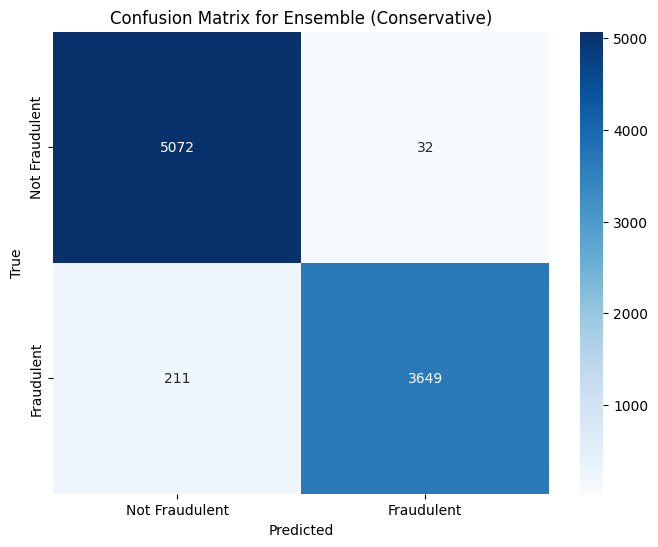

In [ ]:
print("\n" + "="*80)
print("DETAILED ANALYSIS: BEST ENSEMBLE")
print("="*80 + "\n")

best_f1_idx = results_df['F1-Score'].idxmax()
best_ensemble_name = results_df.loc[best_f1_idx, 'Model']
print(f"Best performing ensemble: {best_ensemble_name}")

# Use the best one for detailed analysis
if "Hard" in best_ensemble_name:
    y_pred_best = y_pred_ensemble_hard
    y_pred_proba_best = y_pred_proba_ensemble
elif "Soft" in best_ensemble_name:
    y_pred_best = y_pred_ensemble_soft
    y_pred_proba_best = y_pred_proba_ensemble
elif "Weighted" in best_ensemble_name:
    y_pred_best = y_pred_ensemble_weighted
    y_pred_proba_best = y_pred_proba_ensemble_weighted
else:
    y_pred_best = y_pred_ensemble_conservative
    y_pred_proba_best = y_pred_proba_ensemble

cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()

print(f"\nConfusion Matrix:")
print(cm)
print(f"\nBreakdown:")
print(f"  True Negatives:  {tn}")
print(f"  False Positives: {fp}")
print(f"  False Negatives: {fn}")
print(f"  True Positives:  {tp}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_best))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Not Fraudulent', 'Fraudulent'],
    yticklabels=['Not Fraudulent', 'Fraudulent']
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix for {best_ensemble_name}')
plt.show()


In [ ]:
print("\n" + "="*80)
print("SAVING MODELS")
print("="*80)

lstm_model.save('lstm_model.h5')
print("✓ LSTM model saved")

import pickle
with open('naive_bayes_model.pkl', 'wb') as f:
    pickle.dump(nb_model, f)
print("✓ Naive Bayes model saved")

with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)
print("✓ Vectorizer saved")

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("✓ Tokenizer saved\n")



SAVING MODELS
✓ LSTM model saved
✓ Naive Bayes model saved
✓ Vectorizer saved
✓ Tokenizer saved



: 